# Bayesian Quadrature — Posterior Evolution

**Goal:** Visualize how the Gaussian Process posterior and the integral estimate evolve as observation points are added one by one.

Bayesian Quadrature (BQ) models the unknown integrand as a Gaussian Process (GP). Each time a new function evaluation is observed, the GP posterior updates, and consequently the posterior distribution over the integral changes as well. This notebook makes that process visible.

## What you will see

1. **GP prior** — Before any observations, the GP expresses maximum uncertainty about the integrand.
2. **Sequential posterior updates** — As points are added, the posterior mean approaches the true function and the uncertainty band shrinks near observed locations.
3. **Integral convergence** — The posterior mean of the integral converges toward the true value, while the posterior standard deviation shrinks.
4. **Random vs Active sampling** — Side-by-side comparison showing that active point selection (variance-reduction) can converge faster than random placement.

## Why this matters

The distinctive feature of BQ compared to classical quadrature or Monte Carlo is that it produces a *distribution* over the integral, not just a point estimate. Understanding how this distribution evolves with data is key to understanding the method itself.

In [1]:
import sys, pathlib
_repo_root = str(pathlib.Path().resolve().parent)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from source.kernels.rbf_kernel import RBFKernel
from source.measures.gaussian_measure import GaussianMeasure
from source.measures.uniform_box_measure import UniformBoxMeasure
from source.numeric_integration.bayesian_integral.bayesian_quadrature_model.bayesian_quadrature_model import BayesianQuadratureModel
from source.numeric_integration.bayesian_integral.bayesian_quadrature_model.bayesian_quadrature_config import BQConfig
from source.numeric_integration.bayesian_integral.active_bayesian_quadrature import ActiveBQSelector

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=6, suppress=True)

## 1. Test Function and Ground Truth

We use the integrand $f(x) = \cos(x) + 0.2\,x^2$ under the standard Gaussian measure $\mu = \mathcal{N}(0, 1)$.

The true expectation is:

$$
\mathbb{E}[f(X)] = \mathbb{E}[\cos(X)] + 0.2\,\mathbb{E}[X^2]
= e^{-1/2} + 0.2 \approx 0.8065.
$$

This function is smooth and well-suited for BQ with an RBF kernel, which lets us focus on the *mechanics* of posterior evolution rather than on kernel-function mismatch.

In [2]:
def f_true(x):
    """Scalar integrand: cos(x) + 0.2*x^2."""
    return np.cos(x) + 0.2 * x ** 2

TRUE_INTEGRAL = np.exp(-0.5) + 0.2  # E[cos(X)] + 0.2*E[X^2] under N(0,1)

measure = GaussianMeasure(mean=np.array([0.0]), cov=np.array([[1.0]]))
config = BQConfig(noise=0.0, jitter=1e-8, mc_samples_mean=2048, mc_samples_var=4096)

x_plot = np.linspace(-4, 4, 500).reshape(-1, 1)
f_plot = np.array([f_true(float(x)) for x in x_plot.ravel()])

print(f"True integral E[f(X)] = {TRUE_INTEGRAL:.6f}")

True integral E[f(X)] = 0.806531


## 2. Sequential Posterior Updates — Random Sampling

We start with **zero** observations and add points one at a time, drawn randomly from the measure. At each step we visualize:

- **Left panel:** the GP posterior mean (blue line), the ±2σ credible band (shaded blue), the true function (dashed black), and observed points (red dots).
- **Right panel:** the posterior distribution over the integral $\mathcal{N}(\mu_F, \sigma_F^2)$ shown as a Gaussian bell, with the true integral marked by a vertical red line.

Watch how:
- The credible band shrinks near observed points but stays wide elsewhere.
- The integral posterior tightens around the true value as more data arrives.
- Early observations produce large jumps in the integral estimate; later observations refine it.

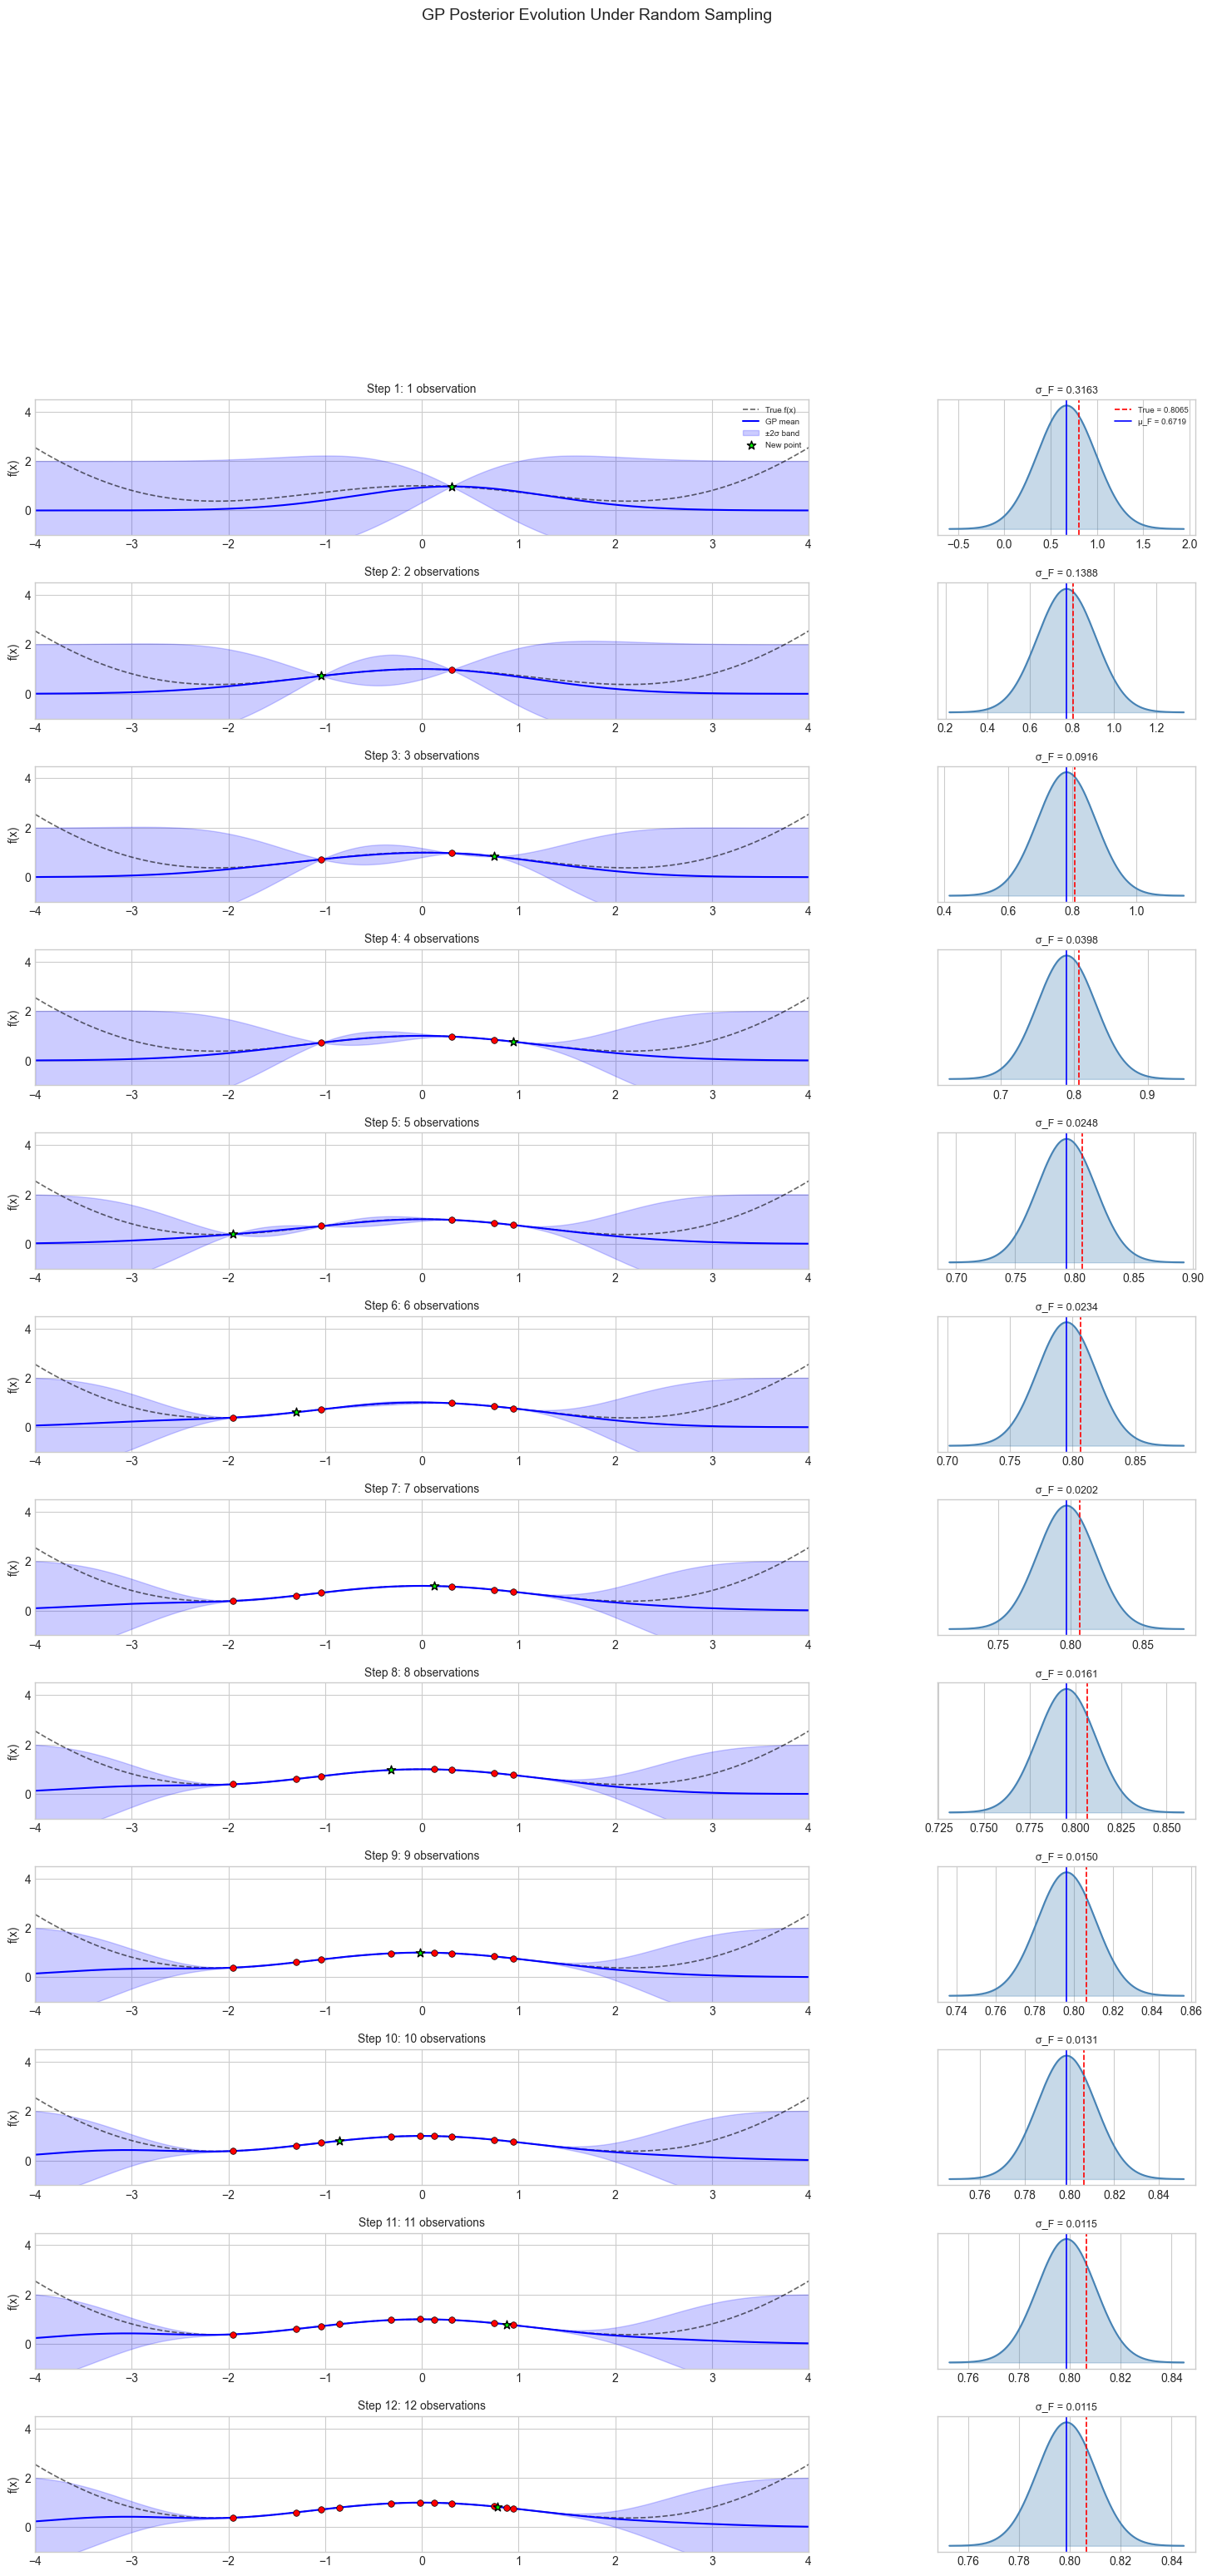

In [ ]:
rng = np.random.default_rng(42)
n_steps = 12
all_X = rng.normal(0, 1, size=(n_steps, 1))
all_y = np.array([f_true(float(x)) for x in all_X.ravel()])

kernel = RBFKernel(lengthscale=1.0, variance=1.0)

fig = plt.figure(figsize=(18, n_steps * 2.8))
outer = GridSpec(n_steps, 2, width_ratios=[3, 1], hspace=0.35, wspace=0.25)

for step in range(1, n_steps + 1):
    X_obs = all_X[:step]
    y_obs = all_y[:step]

    model = BayesianQuadratureModel(kernel, measure, config=config)
    model.fit(X_obs, y_obs)
    mean_F, var_F = model.integral_posterior()
    std_F = np.sqrt(max(var_F, 0.0))

    gp_mean, gp_var = model.predict(x_plot)
    gp_std = np.sqrt(np.maximum(gp_var, 0.0))

    # Left panel: GP posterior
    ax_gp = fig.add_subplot(outer[step - 1, 0])
    ax_gp.plot(x_plot, f_plot, 'k--', lw=1.2, alpha=0.6, label='True f(x)')
    ax_gp.plot(x_plot, gp_mean, 'b-', lw=1.5, label='GP mean')
    ax_gp.fill_between(x_plot.ravel(), gp_mean - 2 * gp_std, gp_mean + 2 * gp_std,
                        alpha=0.2, color='blue', label='±2σ band')
    ax_gp.scatter(X_obs[:-1], y_obs[:-1], c='red', s=30, zorder=5, edgecolors='k', linewidths=0.5)
    ax_gp.scatter(X_obs[-1:], y_obs[-1:], c='lime', s=60, zorder=6, edgecolors='k',
                  linewidths=1.0, marker='*', label='New point')
    ax_gp.set_xlim(-4, 4)
    ax_gp.set_ylim(-1.0, 4.5)
    ax_gp.set_ylabel('f(x)')
    ax_gp.set_title(f'Step {step}: {step} observation{"s" if step > 1 else ""}', fontsize=10)
    if step == 1:
        ax_gp.legend(fontsize=7, loc='upper right')

    # Right panel: Integral posterior
    ax_int = fig.add_subplot(outer[step - 1, 1])
    if std_F > 1e-12:
        z = np.linspace(mean_F - 4 * std_F, mean_F + 4 * std_F, 200)
        pdf = np.exp(-0.5 * ((z - mean_F) / std_F) ** 2) / (std_F * np.sqrt(2 * np.pi))
        ax_int.fill_between(z, pdf, alpha=0.3, color='steelblue')
        ax_int.plot(z, pdf, color='steelblue', lw=1.5)
    ax_int.axvline(TRUE_INTEGRAL, color='red', ls='--', lw=1.2, label=f'True = {TRUE_INTEGRAL:.4f}')
    ax_int.axvline(mean_F, color='blue', ls='-', lw=1.2, label=f'μ_F = {mean_F:.4f}')
    ax_int.set_title(f'σ_F = {std_F:.4f}', fontsize=9)
    ax_int.set_yticks([])
    if step == 1:
        ax_int.legend(fontsize=7)

fig.suptitle('GP Posterior Evolution Under Random Sampling', fontsize=14, y=1.02)
fig.subplots_adjust(top=0.88, wspace=0.3)
plt.show()

## 3. Tracking Convergence Numerically

The plot above is visually informative, but we also want quantitative tracking. Below we plot:

- **Absolute error** $|\mu_F - I^\star|$ vs. number of observations.
- **Posterior standard deviation** $\sigma_F$ vs. number of observations.

If BQ is well-calibrated, the error should generally stay within the posterior uncertainty band, and both quantities should decrease as data accumulates.

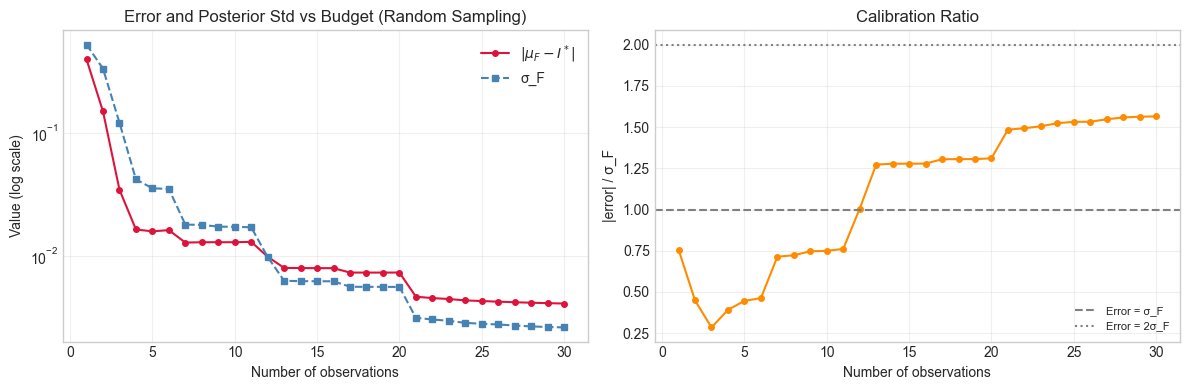

In [4]:
budgets = list(range(1, 31))
rng = np.random.default_rng(123)
all_X_30 = rng.normal(0, 1, size=(30, 1))
all_y_30 = np.array([f_true(float(x)) for x in all_X_30.ravel()])

errors_random = []
stds_random = []

for n in budgets:
    model = BayesianQuadratureModel(kernel, measure, config=config)
    model.fit(all_X_30[:n], all_y_30[:n])
    mean_F, var_F = model.integral_posterior()
    errors_random.append(abs(mean_F - TRUE_INTEGRAL))
    stds_random.append(np.sqrt(max(var_F, 0.0)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(budgets, errors_random, 'o-', ms=4, color='crimson', label=r'$|\mu_F - I^*|$')
axes[0].semilogy(budgets, stds_random, 's--', ms=4, color='steelblue', label='σ_F')
axes[0].set_xlabel('Number of observations')
axes[0].set_ylabel('Value (log scale)')
axes[0].set_title('Error and Posterior Std vs Budget (Random Sampling)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(budgets, [e / s if s > 1e-15 else np.nan for e, s in zip(errors_random, stds_random)],
             'o-', ms=4, color='darkorange')
axes[1].axhline(1.0, ls='--', color='gray', label='Error = σ_F')
axes[1].axhline(2.0, ls=':', color='gray', label='Error = 2σ_F')
axes[1].set_xlabel('Number of observations')
axes[1].set_ylabel('|error| / σ_F')
axes[1].set_title('Calibration Ratio')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Active vs Random Sampling — Side-by-Side Comparison

One of the key advantages of BQ is that the posterior model can guide *where* to evaluate the function next. The **Active BQ** strategy selects each new point to maximize the expected reduction in posterior integral variance.

Below we compare two strategies:
- **Random:** points drawn i.i.d. from the measure.
- **Active (greedy variance-reduction):** each new point is selected from a dense candidate set to minimize the posterior integral variance.

We track both the posterior integral mean error and the posterior standard deviation.

### What to expect
- Active sampling should reduce $\sigma_F$ faster because it deliberately places points where they are most informative for the integral.
- The actual error $|\mu_F - I^\star|$ should also decrease faster, though with occasional non-monotonic behavior due to the stochastic nature of function values.

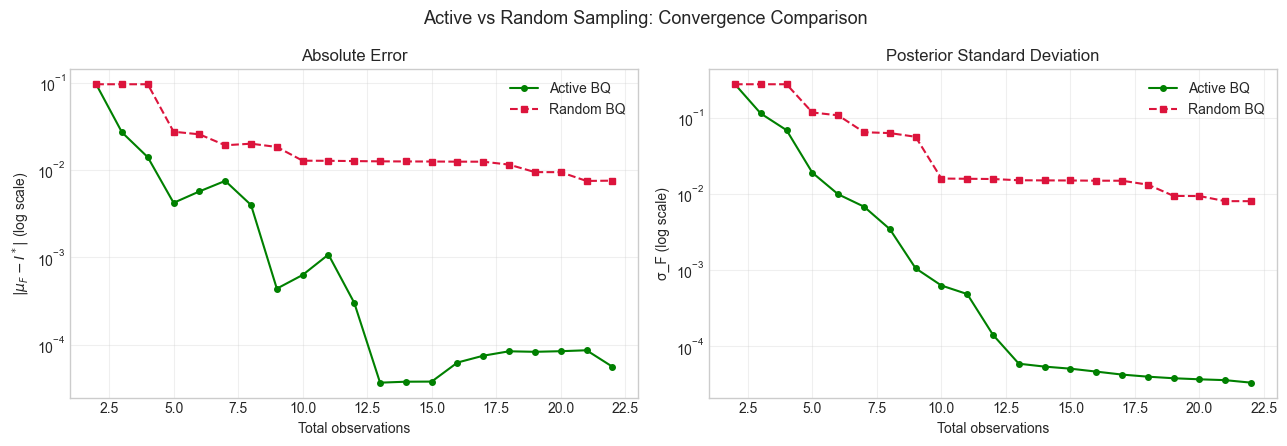

In [6]:
n_active_steps = 20
n_initial = 2

rng_active = np.random.default_rng(7)
X_init = rng_active.normal(0, 1, size=(n_initial, 1))
y_init = np.array([f_true(float(x)) for x in X_init.ravel()])

candidates = np.linspace(-3.5, 3.5, 300).reshape(-1, 1)

# Active sampling
model_active = BayesianQuadratureModel(kernel, measure, config=config)
model_active.fit(X_init.copy(), y_init.copy())

X_active_history = [X_init.copy()]
errors_active = []
stds_active = []
mean_F, var_F = model_active.integral_posterior()
errors_active.append(abs(mean_F - TRUE_INTEGRAL))
stds_active.append(np.sqrt(max(var_F, 0.0)))

for step in range(n_active_steps):
    selector = ActiveBQSelector(model_active)
    best_idx, _, _ = selector.greedy_select(candidates)
    x_new = candidates[best_idx:best_idx + 1]
    y_new = np.array([f_true(float(x_new[0, 0]))])
    model_active.update(x_new, y_new)
    mean_F, var_F = model_active.integral_posterior()
    errors_active.append(abs(mean_F - TRUE_INTEGRAL))
    stds_active.append(np.sqrt(max(var_F, 0.0)))
    X_active_history.append(model_active.dataset.X.copy())

# Random sampling (same initial points, same total budget)
rng_rand = np.random.default_rng(7)
X_rand_all = np.vstack([X_init, rng_rand.normal(0, 1, size=(n_active_steps, 1))])
y_rand_all = np.array([f_true(float(x)) for x in X_rand_all.ravel()])

errors_rand2 = []
stds_rand2 = []
for n in range(n_initial, n_initial + n_active_steps + 1):
    m = BayesianQuadratureModel(kernel, measure, config=config)
    m.fit(X_rand_all[:n], y_rand_all[:n])
    mf, vf = m.integral_posterior()
    errors_rand2.append(abs(mf - TRUE_INTEGRAL))
    stds_rand2.append(np.sqrt(max(vf, 0.0)))

total_points = list(range(n_initial, n_initial + n_active_steps + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].semilogy(total_points, errors_active, 'o-', ms=4, color='green', label='Active BQ')
axes[0].semilogy(total_points, errors_rand2, 's--', ms=4, color='crimson', label='Random BQ')
axes[0].set_xlabel('Total observations')
axes[0].set_ylabel(r'$|\mu_F - I^*|$ (log scale)')
axes[0].set_title('Absolute Error')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(total_points, stds_active, 'o-', ms=4, color='green', label='Active BQ')
axes[1].semilogy(total_points, stds_rand2, 's--', ms=4, color='crimson', label='Random BQ')
axes[1].set_xlabel('Total observations')
axes[1].set_ylabel('σ_F (log scale)')
axes[1].set_title('Posterior Standard Deviation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Active vs Random Sampling: Convergence Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Where Do Active and Random Points Land?

An illuminating way to understand active sampling is to visualize *where* the selected points are placed. Active BQ tends to concentrate points in regions where the integrand-times-measure product is large, since those regions contribute most to the integral.

Below we show the final point placements for both strategies overlaid on the integrand.

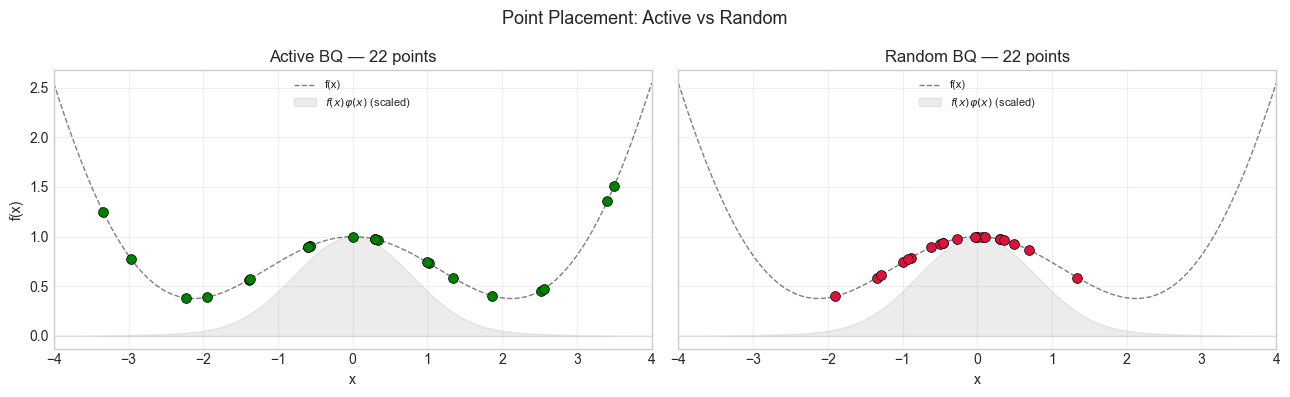

In [8]:
X_active_final = X_active_history[-1]
X_rand_final = X_rand_all[:n_initial + n_active_steps]

gauss_weight = np.exp(-0.5 * x_plot.ravel() ** 2) / np.sqrt(2 * np.pi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, X_pts, title, color in [
    (axes[0], X_active_final, 'Active BQ', 'green'),
    (axes[1], X_rand_final, 'Random BQ', 'crimson'),
]:
    ax.plot(x_plot, f_plot, 'k--', lw=1, alpha=0.5, label='f(x)')
    ax.fill_between(x_plot.ravel(), 0, f_plot * gauss_weight * np.sqrt(2 * np.pi),
                     alpha=0.15, color='gray', label=r'$f(x)\varphi(x)$ (scaled)')
    y_pts = np.array([f_true(float(x)) for x in X_pts[:, 0]])
    ax.scatter(X_pts[:, 0], y_pts, c=color, s=50, zorder=5, edgecolors='k', linewidths=0.5)
    ax.set_title(f'{title} — {len(X_pts)} points')
    ax.set_xlabel('x')
    ax.set_xlim(-4, 4)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('f(x)')
plt.suptitle('Point Placement: Active vs Random', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Posterior Evolution on a Different Function

To confirm that the behavior above is not specific to a single test function, we repeat the evolution experiment with a more challenging integrand:

$$
g(x) = \sin(3x)\,e^{-0.5\,x^2}
$$

under a **uniform measure** on $[-3, 3]$. The true integral is $\int_{-3}^{3} g(x)\,\frac{1}{6}\,dx$, which can be computed to high precision via Gauss-Legendre quadrature.

This function is oscillatory, which means the GP posterior must capture sign changes — a harder task than the smooth function above.

True integral E[g(X)] under Uniform(-3,3) ≈ -0.00000000


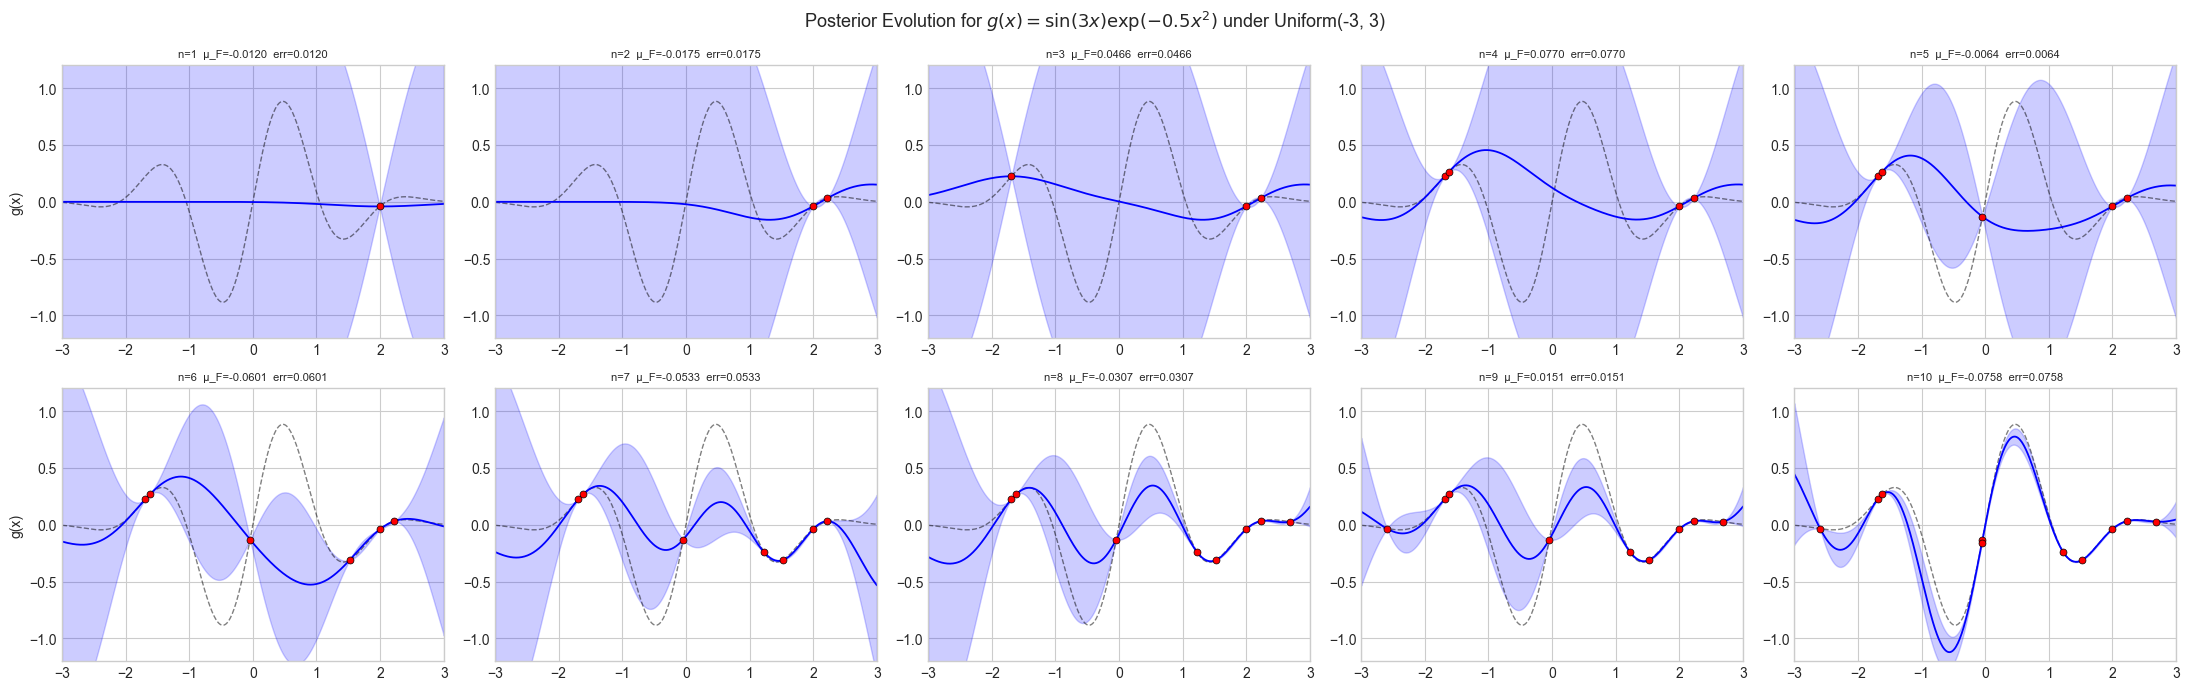

In [7]:
def g_true(x):
    return np.sin(3 * x) * np.exp(-0.5 * x ** 2)

measure_uniform = UniformBoxMeasure(lower=np.array([-3.0]), upper=np.array([3.0]))
kernel_g = RBFKernel(lengthscale=0.8, variance=1.0)

from source.functions.function import Function
from source.functions.domain import Domain
from source.functions.interval import Interval
from source.numeric_integration.numeric_integral_factory.numeric_integral_factory import NumericIntegralFactory
from source.numeric_integration.numeric_integration_pattern import NumericIntegrationPattern

f_leg = Function(lambda x: float(g_true(x)), Domain(Interval(-3.0, 3.0)), name='g')
true_integral_g = NumericIntegralFactory.create(
    NumericIntegrationPattern.LEGENDRE, None, f_leg, 200, Interval(-3.0, 3.0)
).integrate() / 6.0

print(f"True integral E[g(X)] under Uniform(-3,3) ≈ {true_integral_g:.8f}")

x_plot_g = np.linspace(-3, 3, 400).reshape(-1, 1)
f_plot_g = np.array([g_true(float(x)) for x in x_plot_g.ravel()])

rng_g = np.random.default_rng(55)
n_steps_g = 10
X_g = rng_g.uniform(-3, 3, size=(n_steps_g, 1))
y_g = np.array([g_true(float(x)) for x in X_g.ravel()])

fig, axes = plt.subplots(2, 5, figsize=(22, 7))

for step in range(1, n_steps_g + 1):
    m = BayesianQuadratureModel(kernel_g, measure_uniform, config=config)
    m.fit(X_g[:step], y_g[:step])
    gp_mean, gp_var = m.predict(x_plot_g)
    gp_std = np.sqrt(np.maximum(gp_var, 0.0))
    mean_F, var_F = m.integral_posterior()

    ax = axes[(step - 1) // 5, (step - 1) % 5]
    ax.plot(x_plot_g, f_plot_g, 'k--', lw=1, alpha=0.5)
    ax.plot(x_plot_g, gp_mean, 'b-', lw=1.3)
    ax.fill_between(x_plot_g.ravel(), gp_mean - 2 * gp_std, gp_mean + 2 * gp_std,
                     alpha=0.2, color='blue')
    ax.scatter(X_g[:step, 0], y_g[:step], c='red', s=25, zorder=5, edgecolors='k', linewidths=0.5)
    ax.set_title(f'n={step}  μ_F={mean_F:.4f}  err={abs(mean_F - true_integral_g):.4f}', fontsize=8)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-1.2, 1.2)
    if (step - 1) % 5 == 0:
        ax.set_ylabel('g(x)')

fig.suptitle(r'Posterior Evolution for $g(x) = \sin(3x)\exp(-0.5x^2)$ under Uniform(-3, 3)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Key Takeaways

1. **The GP posterior is the backbone of BQ.** Every time a new point is observed, the posterior updates — the mean moves closer to the true function and the variance shrinks locally. The integral posterior inherits these updates because integration is a linear functional.

2. **Early observations have the highest impact.** The first few points dramatically reduce both function-level and integral-level uncertainty. Later points provide diminishing returns, which is consistent with the smoothness assumptions encoded by the RBF kernel.

3. **Active sampling accelerates convergence.** By selecting points that maximize expected variance reduction, active BQ achieves lower posterior uncertainty and lower error than random sampling at the same budget. The advantage is most pronounced in the low-data regime (5–15 observations).

4. **Point placement is interpretable.** Active BQ tends to place points where the integrand-measure product is large or where the GP posterior is most uncertain — exactly where additional information is most valuable for the integral.

5. **Oscillatory functions are harder.** The second experiment shows that when the integrand has sign changes, the GP posterior needs more observations to capture the structure correctly, and the integral estimate can oscillate before settling.